# Zomato Data Analysis 📊

## Objective
Analyze restaurant data to understand trends in ratings, cost, and customer preferences.

In [56]:
import pandas as pd

## Data Loading

In [57]:
df=pd.read_csv(r'C:\Users\lenovo\Pandas Project 1\zomato.csv' , encoding='latin1')

In [85]:
country_df=pd.read_excel(r'C:\Users\lenovo\Pandas Project 1\Country-Code.xlsx')

In [87]:
df=pd.merge(df,country_df,on='Country Code',how='left')

## Data Cleaning

In [58]:
(df['Average Cost for two']==0).sum()

np.int64(18)

In [59]:
import numpy as np
df['Average Cost for two'] = df['Average Cost for two'].replace(0, np.nan)

In [60]:
df.isna().sum()

Restaurant ID            0
Restaurant Name          0
Country Code             0
City                     0
Address                  0
Locality                 0
Locality Verbose         0
Longitude                0
Latitude                 0
Cuisines                 9
Average Cost for two    18
Currency                 0
Has Table booking        0
Has Online delivery      0
Is delivering now        0
Switch to order menu     0
Price range              0
Aggregate rating         0
Rating color             0
Rating text              0
Votes                    0
dtype: int64

In [61]:
df['Cuisines']=df['Cuisines'].fillna('Unknown')

In [62]:
df.duplicated().sum()

np.int64(0)

In [63]:
df['City'].nunique()

141

## Exploratory Data Analysis

In [64]:
df['City'].value_counts().head(10)

City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Bhubaneshwar      21
Lucknow           21
Ahmedabad         21
Amritsar          21
Guwahati          21
Name: count, dtype: int64

In [65]:
df['Cuisines'].value_counts()

Cuisines
North Indian                        936
North Indian, Chinese               511
Fast Food                           354
Chinese                             354
North Indian, Mughlai               334
                                   ... 
Kebab, Turkish Pizza, Dí_ner          1
World Cuisine, Mexican, Italian       1
World Cuisine                         1
Kebab, Izgara                         1
Seafood, Asian, Filipino, Indian      1
Name: count, Length: 1826, dtype: int64

In [66]:
df['Aggregate rating'].mean()

np.float64(2.6663700136111403)

In [67]:
df['Cuisines']=df['Cuisines'].str.split(",")
df_exploded=df.explode('Cuisines')
df_exploded['Cuisines'].value_counts().head(10)

Cuisines
North Indian     2992
 Chinese         1880
 Fast Food       1314
 North Indian     968
Chinese           855
 Mughlai          780
Fast Food         672
Bakery            621
Cafe              617
 Italian          530
Name: count, dtype: int64

In [68]:
df.groupby('City')['Aggregate rating'].mean().reset_index()

,City,Aggregate rating
0,Abu Dhabi,4.300000
1,Agra,3.965000
2,Ahmedabad,4.161905
3,Albany,3.555000
4,Allahabad,3.395000
...,...,...
136,Weirton,3.900000
137,Wellington City,4.250000
138,Winchester Bay,3.200000
139,Yorkton,3.300000


In [69]:
df_filtered=df[df['Votes']>100]
df_filtered.sort_values(by='Aggregate rating',ascending=False)[['Restaurant Name','City','Aggregate rating','Votes']].head(10)

,Restaurant Name,City,Aggregate rating,Votes
1381,Caterspoint,Gurgaon,4.9,223
597,Tresind - Nassima Royal Hotel,Dubai,4.9,1352
124,Rae's Coastal Cafe,Augusta,4.9,548
3,Ooma,Mandaluyong City,4.9,365
9514,Ministry of Crab,Colombo,4.9,203
3013,Naturals Ice Cream,New Delhi,4.9,2620
841,CakeBee,Coimbatore,4.9,200
9296,Talaga Sampireun,Tangerang,4.9,2212
2307,AB's - Absolute Barbecues,Hyderabad,4.9,5434
429,Marukame Udon,Rest of Hawaii,4.9,602


In [88]:

country_exchange_rates = {
    'India': 0.012,
    'United States': 1.0,
    'United Kingdom': 1.25,
    'UAE': 0.27,
    'Brazil': 0.20,
    'South Africa': 0.053,
    'New Zealand': 0.60,
    'Turkey': 0.032,
    'Australia': 0.65,
    'Phillipines': 0.018,
    'Indonesia': 0.000064,
    'Sri Lanka': 0.0033,
    'Qatar': 0.27,
    'Canada': 0.74,
    'Singapore': 0.74
}

def normalize_by_country(row):
    country = row['Country']
    cost = row['Average Cost for two']
    
    if pd.isna(cost):
        return np.nan
        
    if country in country_exchange_rates:
        return cost * country_exchange_rates[country]
    else:
        return cost


df['Cost in USD'] = df.apply(normalize_by_country, axis=1)


In [ ]:
df[['Cost in USD', 'Aggregate rating']].corr()

,Cost in USD,Aggregate rating
Cost in USD,1.000000,0.285024
Aggregate rating,0.285024,1.000000


In [72]:
df.groupby('Has Online delivery')['Aggregate rating'].mean()

Has Online delivery
No     2.465296
Yes    3.248837
Name: Aggregate rating, dtype: float64

In [73]:
city_states=df.groupby('City').agg({'Aggregate rating':'mean','Restaurant ID':'count'})

In [74]:
city_states.columns=['avg. rating','number of restaurants']

In [75]:
city_states.sort_values(by=['avg. rating','number of restaurants'],ascending=False).head(10)

,avg. rating,number of restaurants
City,,
Inner City,4.900000,2
Quezon City,4.800000,1
Makati City,4.650000,2
Pasig City,4.633333,3
Mandaluyong City,4.625000,4
Beechworth,4.600000,1
London,4.535000,20
Taguig City,4.525000,4
Secunderabad,4.500000,2


In [76]:
under_rated=df[(df['Aggregate rating']>=4.5)&(df['Votes']<=50)]

In [77]:
under_rated[['Aggregate rating','Votes']].sort_values(by=['Aggregate rating'],ascending=False).head(10)

,Aggregate rating,Votes
39,4.9,30
48,4.9,40
50,4.9,49
850,4.9,50
47,4.8,19
43,4.8,29
59,4.7,44
44,4.7,24
60,4.6,24
49,4.6,21


## Visualization

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

In [79]:
df['City']=df['City'].str.lower().str.strip()

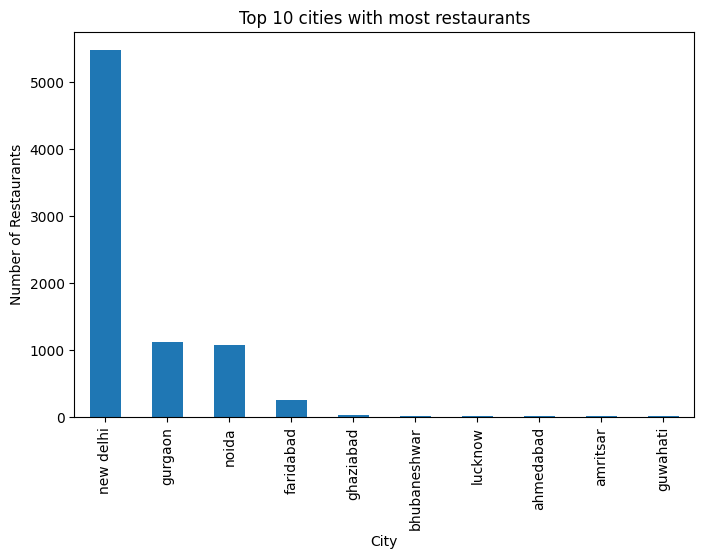

In [80]:
plt.figure(figsize=(8,5))
top_cities=df['City'].value_counts().head(10)
top_cities.plot(kind='bar')
plt.title('Top 10 cities with most restaurants')
plt.xlabel('City')
plt.ylabel('Number of Restaurants')
plt.show()

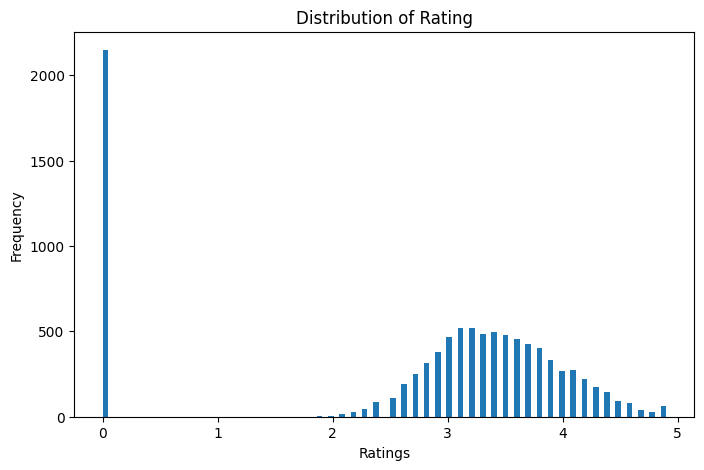

In [81]:
plt.figure(figsize=(8,5))
plt.hist(df['Aggregate rating'],bins=100)
plt.title('Distribution of Rating')
plt.xlabel('Ratings')
plt.ylabel('Frequency')
plt.show()

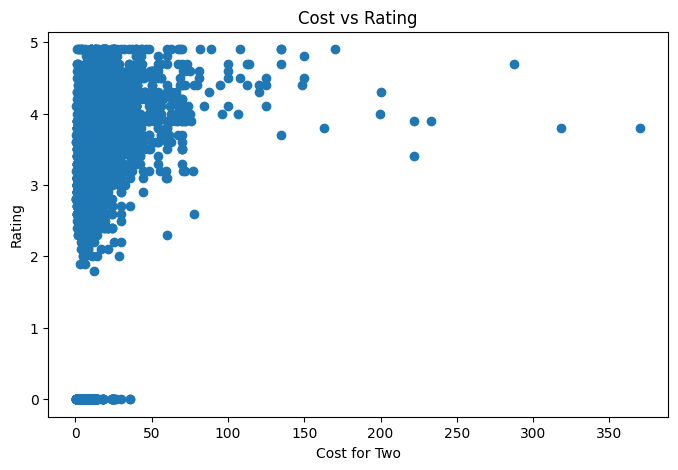

In [89]:
plt.figure(figsize=(8,5))
plt.scatter(df['Cost in USD'],df['Aggregate rating'])
plt.xlabel('Cost for Two')
plt.ylabel('Rating')
plt.title('Cost vs Rating')
plt.show()

In [90]:
(df['Cost in USD']==0).sum()

np.int64(0)

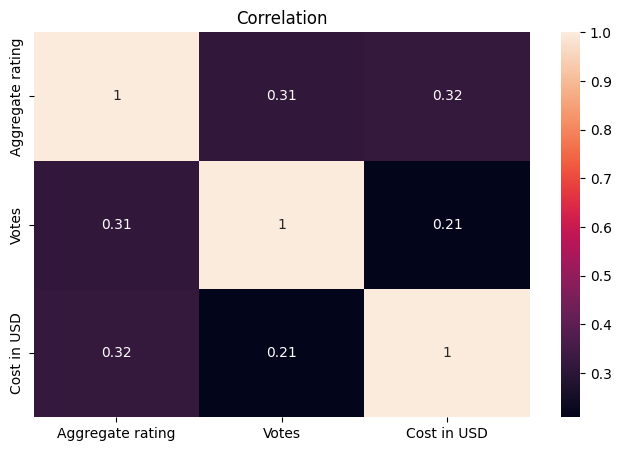

In [91]:
plt.figure(figsize=(8,5))
corr=df[['Aggregate rating','Votes','Cost in USD']].corr()
sns.heatmap(corr,annot=True)
plt.title('Correlation')
plt.show()

## Insights

1. New Delhi and Gurgaon have the highest number of restaurants, indicating higher demand and greater urban density

2. North Indian and Chinese cuisines dominate the dataset, showing strong consumer preference for these categories.

3. The average rating per city mostly ranges between 3.5 and 4.5 indicating general positive consumer experience

4. There is no strong correlation between cost and rating, suggesting that higher price does not guarantee better quality.

5. Restaurants offering online delivery tend to have slightly higher ratings, possibly due to convenience.

6. Some entries had zero cost values, which were treated as missing data and removed to ensure accurate analysis.

7. Cost data is highly skewed due to a few high-value outliers, affecting visualization and interpretation.

## Conclusion
This analysis reveals key trends in restaurant distribution, pricing, and customer preferences. The dataset shows that affordability does not necessarily impact ratings, and urban cities dominate the food industry.